# Landsat 8 STAC Exploration: Search, Preview RGB, and Download Last-Month Data

This notebook shows a practical Landsat 8 workflow using the Microsoft Planetary Computer STAC API.

What STAC gives you:
- A **Catalog**: entry point to collections.
- A **Collection**: grouped dataset (here: `landsat-c2-l2`, filtered to `platform=landsat-8`).
- An **Item**: one scene/acquisition with metadata (date, cloud cover, geometry, assets).
- **Assets**: downloadable files (bands like `blue`, `green`, `red`, plus QA layers).

What we will do:
1. Create a signed STAC client.
2. Search recent Landsat 8 items for a bbox.
3. Inspect one item (ID, date, cloud cover, available assets).
4. Download RGB bands for the most recent item and render an RGB preview.
5. Download a one-month set of key bands to local disk.

Common pitfalls:
- Cloud filtering can return zero items for short windows.
- Some assets may be missing for specific scenes.
- Downloads can be large; reruns should skip existing files.

## 2) Environment Setup

Install dependencies once in your environment:

`uv add pystac-client planetary-computer python-dateutil requests rasterio numpy matplotlib`

This notebook assumes these packages are already installed.

## 3) Imports + Parameters

We define one bbox, a cloud threshold, and a small result limit for exploration.

In [30]:
import pystac_client
import planetary_computer
from datetime import date
from dateutil.relativedelta import relativedelta
import requests
from pathlib import Path

import rasterio
import numpy as np
import matplotlib.pyplot as plt
lon = 30.999312
lat = 30.605991

# elkom elakhadr city, egypt
buffer_deg = 0.01   # ≈2 km

# [min_lon, min_lat, max_lon, max_lat]
bbox = [
    lon - buffer_deg,  # west
    lat - buffer_deg,  # south
    lon + buffer_deg,  # east
    lat + buffer_deg   # north
]
max_cloud = 5.0

## 4) Create STAC Client

Planetary Computer assets need signed URLs. Using `modifier=planetary_computer.sign_inplace` signs Items/Assets as they are read, which helps avoid common authorization/HTTP 409-style access problems.

In [31]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

print("Connected to:", catalog.title or "Planetary Computer STAC")

Connected to: Microsoft Planetary Computer STAC API


## 5) Search Recent Items

We search the last 7 days with a cloud filter and small limit. Then we inspect one Item to understand its structure.

If you get zero results, widen the date range or relax cloud filtering.

In [32]:
end_recent = date.today()
start_recent = end_recent - relativedelta(days=7)
recent_dt = f"{start_recent.isoformat()}/{end_recent.isoformat()}"

search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,
    datetime=recent_dt,
    query={"eo:cloud_cover": {"lt": max_cloud}, "platform": {"eq": "landsat-8"}},
    limit=5
)

items = list(search.items())
print(f"Found {len(items)} item(s) in {recent_dt} with cloud < {max_cloud}%")

if not items:
    raise RuntimeError(
        "No recent items found. Try increasing `limit` if used, widening date window, or raising `max_cloud`."
    )

first_item = items[0]
print("\nFirst item preview")
print("id:", first_item.id)
print("datetime:", first_item.datetime)
print("eo:cloud_cover:", first_item.properties.get("eo:cloud_cover"))
print("assets (first 10):", list(first_item.assets.keys())[:10])

Found 1 item(s) in 2026-01-30/2026-02-06 with cloud < 5.0%

First item preview
id: S2B_MSIL2A_20260204T084039_R064_T36RTU_20260204T130007
datetime: 2026-02-04 08:40:39.024000+00:00
eo:cloud_cover: 4.64015
assets (first 10): ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09']


## 6) Pick the Most Recent Item

STAC search order may vary. We sort by `item.datetime` descending and keep the newest scene.

In [33]:
items_sorted = sorted(items, key=lambda item: item.datetime, reverse=True)
latest_item = items_sorted[0]

print("Latest item:", latest_item.id)
print("Datetime:", latest_item.datetime)
print("Cloud cover:", latest_item.properties.get("eo:cloud_cover"))

Latest item: S2B_MSIL2A_20260204T084039_R064_T36RTU_20260204T130007
Datetime: 2026-02-04 08:40:39.024000+00:00
Cloud cover: 4.64015


## 7) Load RGB Bands for Latest Item (In Memory)

we read `blue`, `green`, and `red` directly from signed STAC asset URLs.

Implementation notes:
- No local writes for this quick preview.
- Raises a clear error if a required asset key is missing.
- This is convenient for exploration, but network speed still affects load time.

In [ ]:
required_rgb_bands = ["blue", "green", "red"]
missing = [band for band in required_rgb_bands if band not in latest_item.assets]
if missing:
    available = ", ".join(sorted(latest_item.assets.keys()))
    raise KeyError(
        f"Latest item {latest_item.id} is missing required asset(s): {missing}. Available assets: {available}"
    )

band_arrays = {}

for band in required_rgb_bands:
    url = latest_item.assets[band].href
    print(f"[read] {band} from signed URL")
    with rasterio.open(url) as src:
        band_arrays[band] = src.read(1).astype(np.float32)

red = band_arrays["red"]
green = band_arrays["green"]
blue = band_arrays["blue"]

rgb = np.dstack([red, green, blue])
rgb = np.clip(rgb / 3000, 0, 1)
print("RGB array prepared in memory.", rgb.shape)

[read] B02 from signed URL


## 8) Render RGB with Matplotlib

Now we render the in-memory RGB array prepared in Step 7.

Tip: If the image looks too dark/bright, adjust the divisor (for example 2000 to 5000).

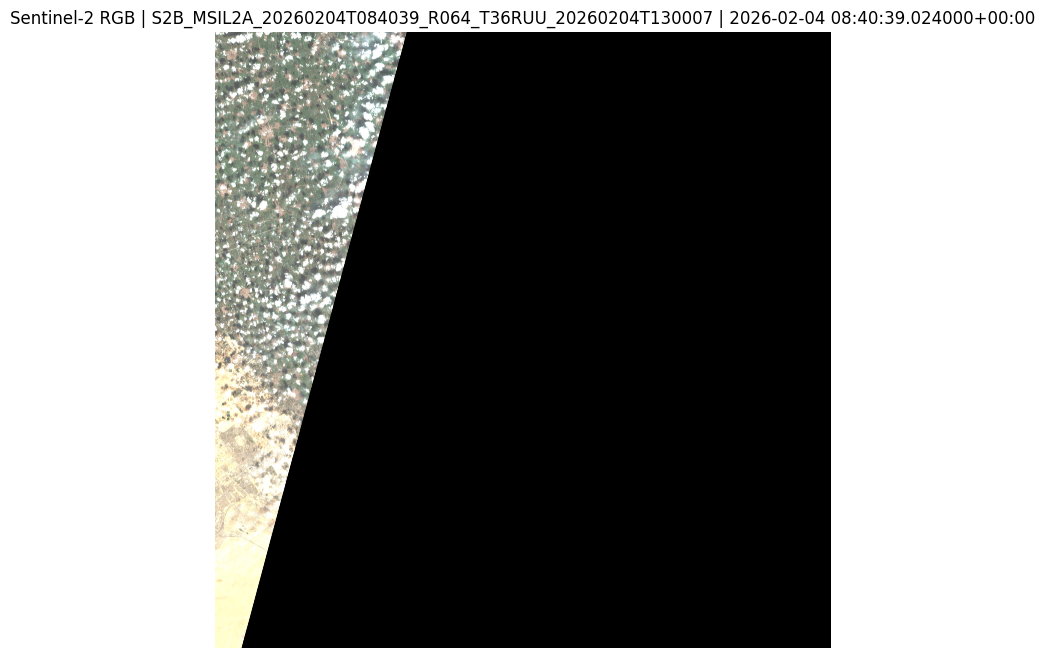

In [6]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title(f"Landsat 8 RGB | {latest_item.id} | {latest_item.datetime}")
plt.axis("off")
plt.show()

## 9) Final: Download One Month of Data

Now we search one month back from today and download key Landsat 8 assets per item:
- Spectral bands: `coastal`, `blue`, `green`, `red`, `nir08`, `swir16`, `swir22`, `lwir11`
- QA layers: `qa_pixel`, `qa_radsat`

Notes:
- This uses `limit`, so it may not capture every scene in dense periods.
- Increase `limit` (or paginate) for broader coverage.
- Missing assets are skipped with a warning.

In [ ]:
end_date = date.today()
start_date = end_date - relativedelta(months=1)
month_dt = f"{start_date.isoformat()}/{end_date.isoformat()}"

month_search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,
    datetime=month_dt,
    query={"eo:cloud_cover": {"lt": max_cloud}, "platform": {"eq": "landsat-8"}},
)

month_items = list(month_search.items())
print(f"Found {len(month_items)} item(s) in {month_dt} with cloud < {max_cloud}%")

bands_to_download = [
    "coastal", "blue", "green", "red", "nir08",
    "swir16", "swir22", "lwir11", "qa_pixel", "qa_radsat"
]
downloaded_count = 0
skipped_count = 0

for item in month_items:
    item_dir = Path("landsat8_data") / item.id
    item_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nItem: {item.id} | datetime: {item.datetime} | cloud: {item.properties.get('eo:cloud_cover')}")

    for band in bands_to_download:
        if band not in item.assets:
            print(f"  [warn] Missing asset {band}; skipping")
            continue

        out_path = item_dir / f"{item.id}_{band}.tif"
        if out_path.exists():
            skipped_count += 1
            print(f"  [skip] {out_path.name}")
            continue

        url = item.assets[band].href
        print(f"  [download] {out_path.name}")
        with requests.get(url, stream=True, timeout=120) as response:
            response.raise_for_status()
            with open(out_path, "wb") as f:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)

        downloaded_count += 1

print("\nSummary")
print(f"Items processed: {len(month_items)}")
print(f"Files downloaded: {downloaded_count}")
print(f"Files skipped (already existed): {skipped_count}")